In [1]:
import numpy as np 
import torch

seed = 13202050 # replace with your student ID
np.random.seed(seed) 
torch.manual_seed(seed)

f = lambda x: torch.sin(torch.exp(x[:,0])+ x[:,1])

train_input = torch.zeros(1000, 2) # 1000 samples, 2 variables
train_ranges = np.array([0, 0.5] * 2).reshape(2, 2)

test_input = torch.zeros(1000, 2)
test_ranges = np.array([0.5, 1] * 2).reshape(2, 2)

for i in range(2):
    train_input[:, i] = ( 
        torch.rand( 
            1000 , 
        )
        * (train_ranges[i, 1] - train_ranges[i, 0]) 
        + train_ranges[i, 0]
    )   
    test_input[:, i] = (
        torch.rand(
            1000 , 
        )
        * (test_ranges[i, 1] - test_ranges[i, 0]) 
        + test_ranges[i, 0]
    )
train_label = f(train_input)
test_label = f(test_input)

In [2]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np

np.random.seed(42)


def square_loss(targets, predictions):
    loss = 0
    for t, p in zip(targets, predictions):
        loss += (t - p) ** 2
    loss = loss / len(targets)
    return 0.5 * loss

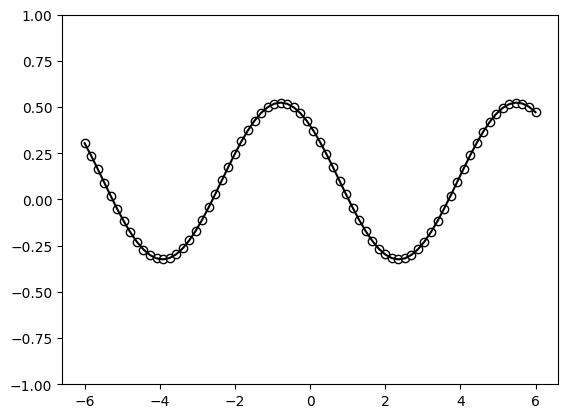

In [3]:
degree = 1  # degree of the target function
scaling = 1  # scaling of the data
coeffs = [0.15 + 0.15j] * degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency


def target_function(x):
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = coeff0
    for idx, coeff in enumerate(coeffs):
        exponent = np.complex128(scaling * (idx + 1) * x * 1j)
        conj_coeff = np.conjugate(coeff)
        res += coeff * np.exp(exponent) + conj_coeff * np.exp(-exponent)
    return np.real(res)
x = np.linspace(-6, 6, 70, requires_grad=False)
target_y = np.array([target_function(x_) for x_ in x], requires_grad=False)

plt.plot(x, target_y, c="black")
plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.ylim(-1, 1)
plt.show()

In [4]:
scaling = 1

dev = qml.device("default.qubit", wires=1)


def S(x):
    """Data-encoding circuit block."""
    qml.RX(scaling * x, wires=0)


def W(theta):
    """Trainable circuit block."""
    qml.Rot(theta[0], theta[1], theta[2], wires=0)


@qml.qnode(dev)
def serial_quantum_model(weights, x):

    for theta in weights[:-1]:
        W(theta)
        S(x)

    # (L+1)'th unitary
    W(weights[-1])

    return qml.expval(qml.PauliZ(wires=0))

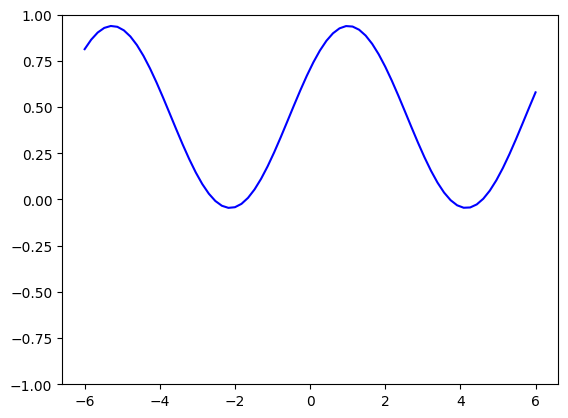

In [5]:
r = 1  # number of times the encoding gets repeated (here equal to the number of layers)
weights = (
    2 * np.pi * np.random.random(size=(r + 1, 3), requires_grad=True)
)  # some random initial weights

x = np.linspace(-6, 6, 70, requires_grad=False)
random_quantum_model_y = [serial_quantum_model(weights, x_) for x_ in x]

plt.plot(x, random_quantum_model_y, c="blue")
plt.ylim(-1, 1)
plt.show()

In [6]:
def cost(weights, x, y):
    predictions = [serial_quantum_model(weights, x_) for x_ in x]
    return square_loss(y, predictions)


max_steps = 50
opt = qml.AdamOptimizer(0.3)
batch_size = 25
cst = [cost(weights, x, target_y)]  # initial cost

for step in range(max_steps):

    # Select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # Update the weights by one optimizer step
    weights, _, _ = opt.step(cost, weights, x_batch, y_batch)

    # Save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cst.append(c)
    if (step + 1) % 10 == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

Cost at step  10: 0.11428002647555736
Cost at step  20: 0.012640683454725538
Cost at step  30: 0.0021405817315259695
Cost at step  40: 0.0019322449091532556
Cost at step  50: 0.0001336053324190094


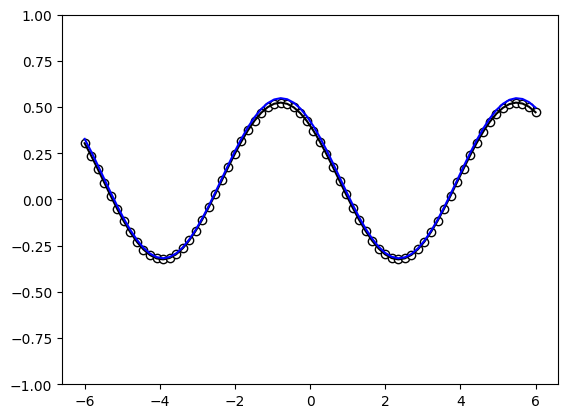

In [7]:
predictions = [serial_quantum_model(weights, x_) for x_ in x]

plt.plot(x, target_y, c="black")
plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.plot(x, predictions, c="blue")
plt.ylim(-1, 1)
plt.show()

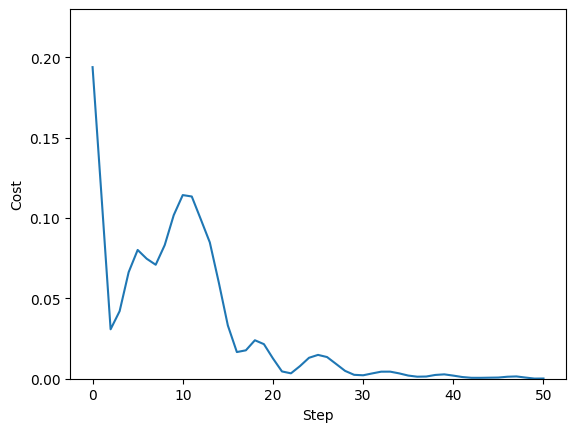

In [8]:
plt.plot(range(len(cst)), cst)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.ylim(0, 0.23)
plt.show()

***

**Case 1**


Step 0: Loss = 2.7506607715135742
Step 10: Loss = 0.01042874030237009
Step 20: Loss = 0.00979812828121665
Step 30: Loss = 0.023821399504385433
Step 40: Loss = 0.010892524366138906
Step 50: Loss = 0.0019134650486435953
Step 60: Loss = 0.0009769699489246433
Step 70: Loss = 0.0007548629217764873
Step 80: Loss = 0.0006938569965185317
Step 90: Loss = 0.0006825046293205976


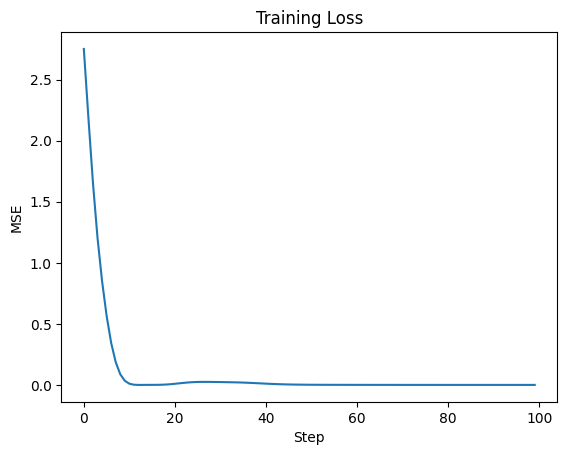

Test Loss: 0.38602069901954783
Train MSE: 0.0006808215615529953
Test  MSE: 0.38602069901954783


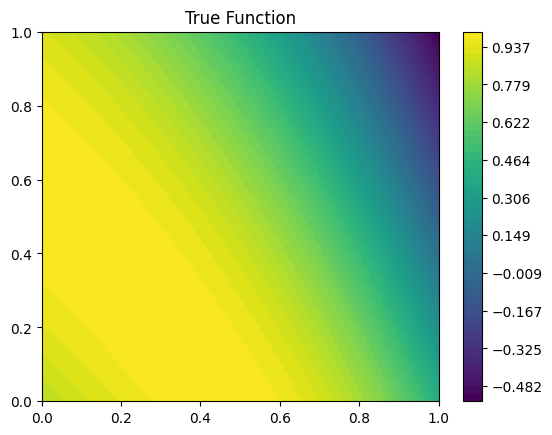

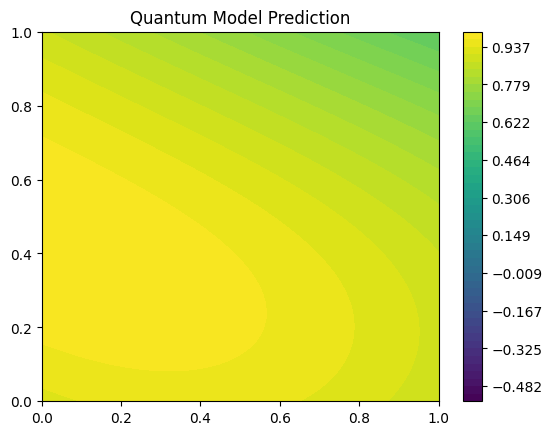

In [ ]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=1)
scaling = 1

def S(x):
    # 2D encoding
    qml.RX(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=0)

def W(theta):
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 1  # try 1, 3, 5 to see expressivity difference
weights = torch.randn((r+1, 3), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


**Case 3**


Step 0: Loss = 0.810183771144963
Step 10: Loss = 0.08312383484005127
Step 20: Loss = 0.019300802278675425
Step 30: Loss = 0.01083074749060345
Step 40: Loss = 0.007842867615549103
Step 50: Loss = 0.006778142473222063
Step 60: Loss = 0.005985577335344885
Step 70: Loss = 0.0050883931937932714
Step 80: Loss = 0.0040792889855762356
Step 90: Loss = 0.0030294625071062907


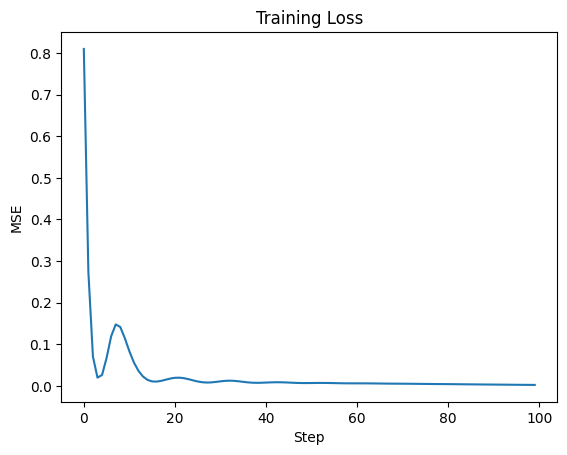

Test Loss: 0.04170502447116429
Train MSE: 0.002099380551147092
Test  MSE: 0.04170502447116429


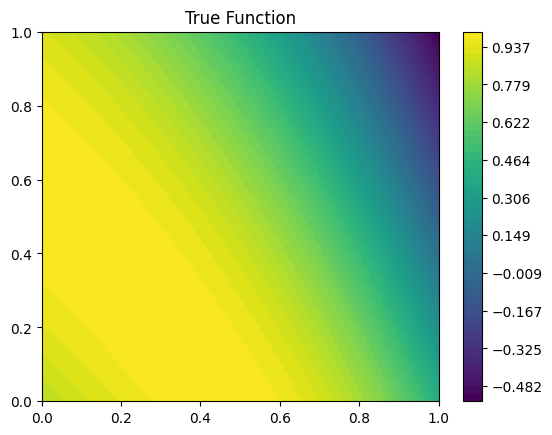

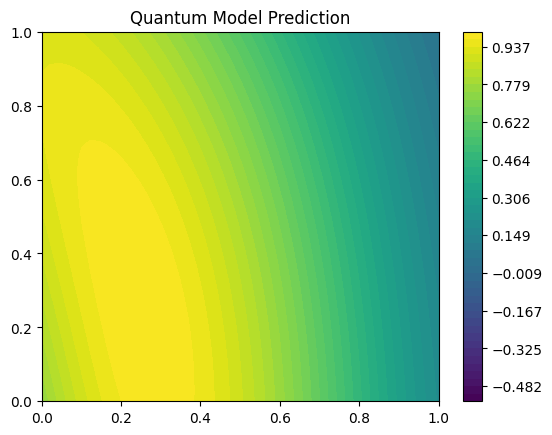

In [ ]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=1)
scaling = 1

def S(x):
    # 2D encoding
    qml.RX(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=0)

def W(theta):
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 3  # try 1, 3, 5 to see expressivity difference
weights = torch.randn((r+1, 3), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


**Case 5**


Step 0: Loss = 1.0641349891659797
Step 10: Loss = 0.013418215563231353
Step 20: Loss = 0.006081369452679567
Step 30: Loss = 0.006256899536211773
Step 40: Loss = 0.003257848343938716
Step 50: Loss = 0.0015523270182693906
Step 60: Loss = 0.000784460333379915
Step 70: Loss = 0.0004701089444273273
Step 80: Loss = 0.00033407162455905114
Step 90: Loss = 0.00025775066550146985


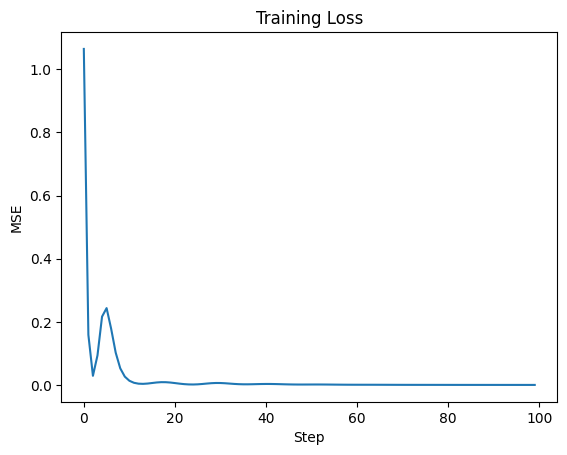

Test Loss: 0.06328190658346758
Train MSE: 0.00021948358196095715
Test  MSE: 0.06328190658346758


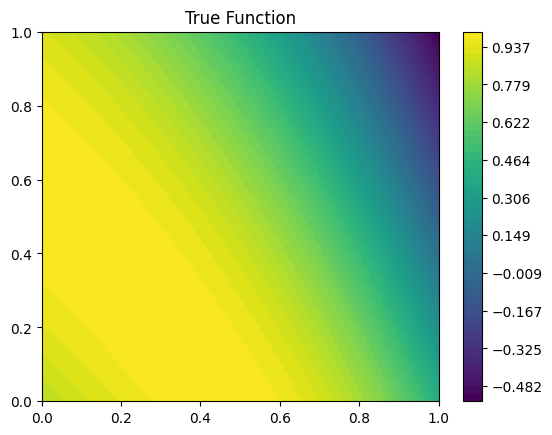

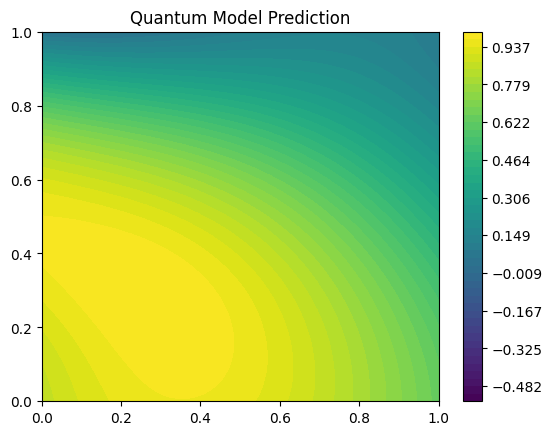

In [ ]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=1)
scaling = 1

def S(x):
    # 2D encoding
    qml.RX(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=0)

def W(theta):
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 5  # try 1, 3, 5 to see expressivity difference
weights = torch.randn((r+1, 3), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


**Case 4**


Step 0: Loss = 0.5666031875283475
Step 10: Loss = 0.014731663538972976
Step 20: Loss = 0.0042411924837357
Step 30: Loss = 0.0016052764396984297
Step 40: Loss = 0.0012258769429181564
Step 50: Loss = 0.0009678465504672178
Step 60: Loss = 0.0007880797606523842
Step 70: Loss = 0.0006595932023768488
Step 80: Loss = 0.0006430112511596348
Step 90: Loss = 0.0006380778652571186


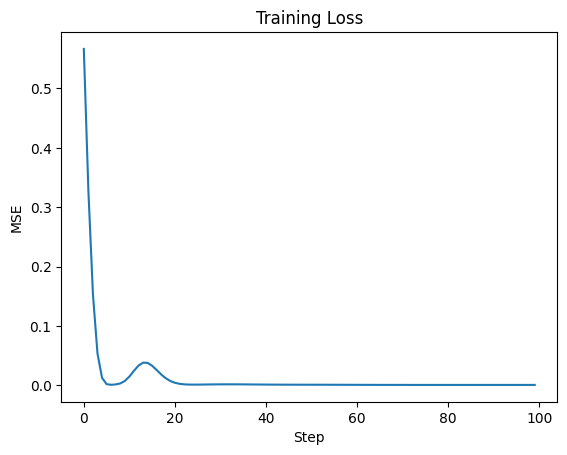

Test Loss: 0.12189397166586914
Train MSE: 0.0006346604255666428
Test  MSE: 0.12189397166586914


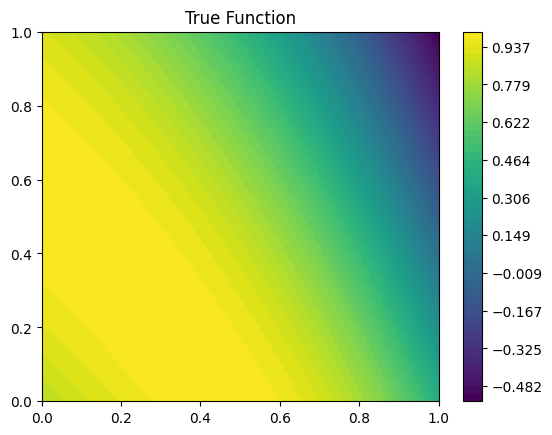

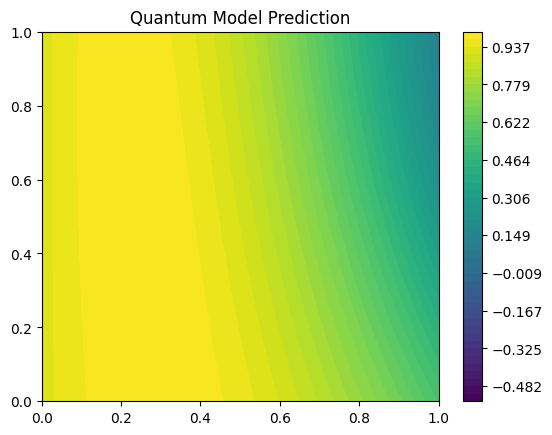

In [ ]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=2)
scaling = 1

def S(x):
    qml.RY(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=1)

    qml.RZ(scaling * x[0], wires=0)
    qml.RZ(scaling * x[1], wires=1)

    qml.CNOT(wires=[0, 1])
    qml.RZ(scaling * x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])


def W(theta):
    qml.Rot(theta[0, 0], theta[1, 0], theta[2, 0], wires=0)
    qml.Rot(theta[0, 1], theta[1, 1], theta[2, 1], wires=1)
    qml.CZ(wires=[0, 1])
@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 1  
weights = torch.randn((r+1, 3, 2), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


**Case 4**

Step 0: Loss = 2.1208235076414286
Step 10: Loss = 0.1108464514401329
Step 20: Loss = 0.005480068816315911
Step 30: Loss = 0.01141488394334405
Step 40: Loss = 0.0006347343245475716
Step 50: Loss = 0.00045776482025822055
Step 60: Loss = 0.00018984362526852067
Step 70: Loss = 9.99755114977133e-05
Step 80: Loss = 5.9131117981971944e-05
Step 90: Loss = 4.569588077252539e-05


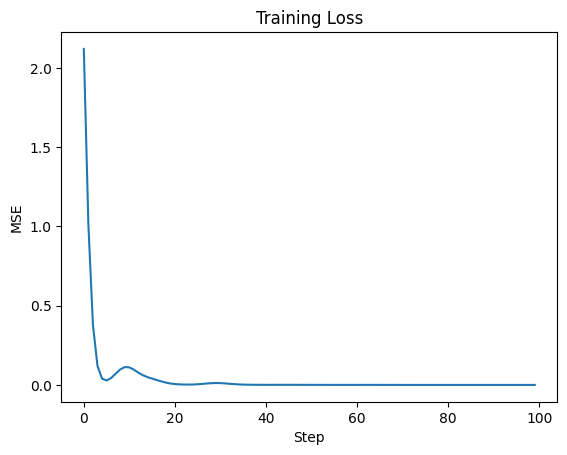

Test Loss: 0.07507568877835478
Train MSE: 4.3390894023476326e-05
Test  MSE: 0.07507568877835478


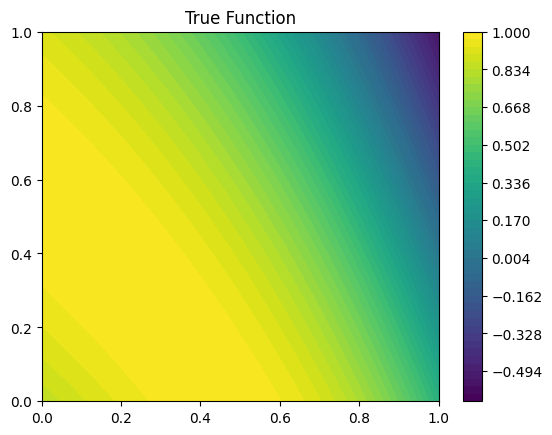

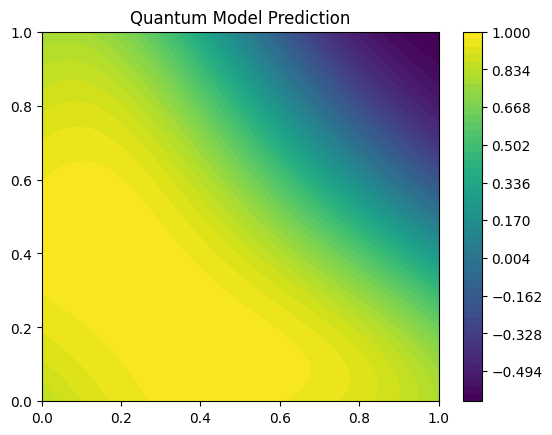

In [ ]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=2)
scaling = 1

def S(x):
    qml.RY(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=1)

    qml.RZ(scaling * x[0], wires=0)
    qml.RZ(scaling * x[1], wires=1)

    qml.CNOT(wires=[0, 1])
    qml.RZ(scaling * x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])


def W(theta):
    qml.Rot(theta[0, 0], theta[1, 0], theta[2, 0], wires=0)
    qml.Rot(theta[0, 1], theta[1, 1], theta[2, 1], wires=1)
    qml.CZ(wires=[0, 1])
@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 3 
weights = torch.randn((r+1, 3, 2), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


**Case 6**

Step 0: Loss = 0.880464051479506
Step 10: Loss = 0.05006946699677397
Step 20: Loss = 0.00472710328973111
Step 30: Loss = 0.003690388853975106
Step 40: Loss = 0.0015771444607200044
Step 50: Loss = 0.0009017857674189307
Step 60: Loss = 0.0007192586071109976
Step 70: Loss = 0.0005772099440003318
Step 80: Loss = 0.00041641797468378093
Step 90: Loss = 0.00028001510589615783


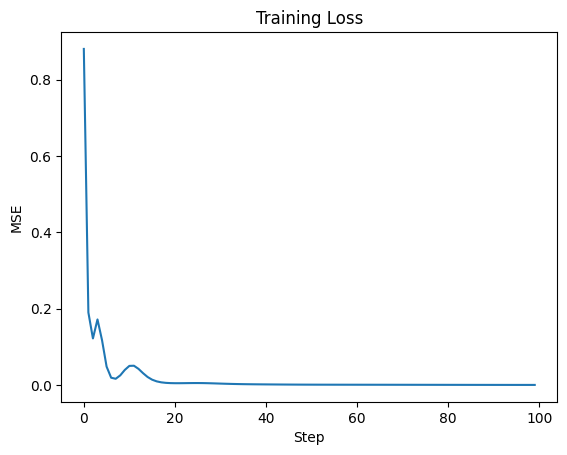

Test Loss: 0.21253662721975997
Train MSE: 0.00021195091571870928
Test  MSE: 0.21253662721975997


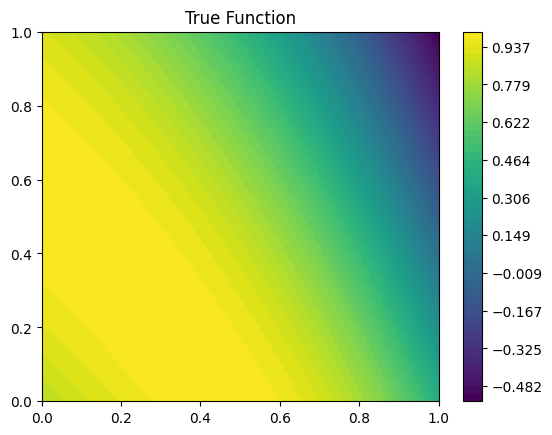

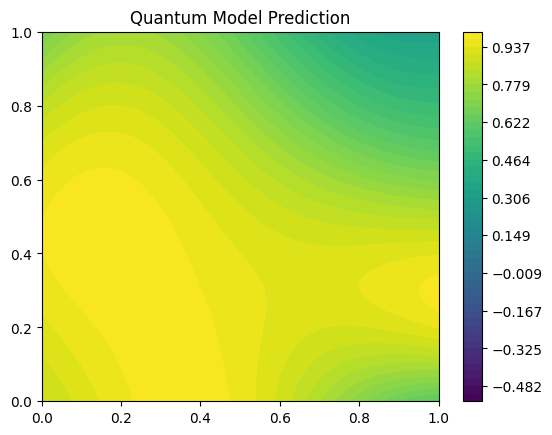

In [ ]:
# ====== Full Pipeline: Torch + PennyLane (2D Quantum Model) ======

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# ----------------------
# 1. Seed
# ----------------------
seed = 13202050
torch.manual_seed(seed)

# ----------------------
# 2. Target function (2D)
# f(x1, x2) = sin(exp(x1) + x2)
# ----------------------
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ----------------------
# 3. Generate data
# ----------------------
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = (
        torch.rand(N)
        * (train_ranges[i, 1] - train_ranges[i, 0])
        + train_ranges[i, 0]
    )
    
    test_input[:, i] = (
        torch.rand(N)
        * (test_ranges[i, 1] - test_ranges[i, 0])
        + test_ranges[i, 0]
    )

train_label = f(train_input)
test_label  = f(test_input)

# ----------------------
# 4. Quantum Model
# ----------------------
dev = qml.device("default.qubit", wires=2)
scaling = 1

def S(x):
    qml.RY(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=1)

    qml.RZ(scaling * x[0], wires=0)
    qml.RZ(scaling * x[1], wires=1)

    qml.CNOT(wires=[0, 1])
    qml.RZ(scaling * x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])


def W(theta):
    qml.Rot(theta[0, 0], theta[1, 0], theta[2, 0], wires=0)
    qml.Rot(theta[0, 1], theta[1, 1], theta[2, 1], wires=1)
    qml.CZ(wires=[0, 1])
@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ----------------------
# 5. Initialize weights
# ----------------------
r = 5
weights = torch.randn((r+1, 3, 2), requires_grad=True)

# ----------------------
# 6. Optimizer
# ----------------------
optimizer = torch.optim.Adam([weights], lr=0.1)

# ----------------------
# 7. Training loop
# ----------------------
steps = 100
loss_history = []

for step in range(steps):
    
    optimizer.zero_grad()
    
    preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    
    loss = torch.mean((preds - train_label)**2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss = {loss.item()}")

# ----------------------
# 8. Plot loss
# ----------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ----------------------
# 9. Evaluate on test set
# ----------------------
with torch.no_grad():
    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_loss = torch.mean((test_preds - test_label)**2)

print(f"Test Loss: {test_loss.item()}")
# ----------------------
# 10. Compute Train/Test MSE
# ----------------------
with torch.no_grad():
    train_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in train_input
    ])
    train_mse = torch.mean((train_preds - train_label)**2)

    test_preds = torch.stack([
        serial_quantum_model(weights, x_) for x_ in test_input
    ])
    test_mse = torch.mean((test_preds - test_label)**2)

print(f"Train MSE: {train_mse.item()}")
print(f"Test  MSE: {test_mse.item()}")

# ----------------------
# 11. Visualization (2D contour)
# ----------------------
x1 = torch.linspace(0, 1, 50)
x2 = torch.linspace(0, 1, 50)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

for i in range(50):
    for j in range(50):
        Z_pred[i, j] = serial_quantum_model(weights, torch.tensor([X1[i,j], X2[i,j]]))

# 統一 color scale
vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = torch.linspace(vminn, vmaxx, 50).numpy()

# True
plt.contourf(
    X1.numpy(), X2.numpy(), Z_true.numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("True Function")
plt.colorbar()
plt.show()

# Prediction
plt.contourf(
    X1.numpy(), X2.numpy(), Z_pred.detach().numpy(),
    levels=levels, vmin=vminn, vmax=vmaxx
)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()


***
**1.3** The Fourier spectrum

Step   0 | Train Loss = 2.120824
Step  10 | Train Loss = 0.110846
Step  20 | Train Loss = 0.005480
Step  30 | Train Loss = 0.011415
Step  40 | Train Loss = 0.000635
Step  50 | Train Loss = 0.000458
Step  60 | Train Loss = 0.000190
Step  70 | Train Loss = 0.000100
Step  80 | Train Loss = 0.000059
Step  90 | Train Loss = 0.000046

Train MSE = 0.000043
Test  MSE = 0.075076


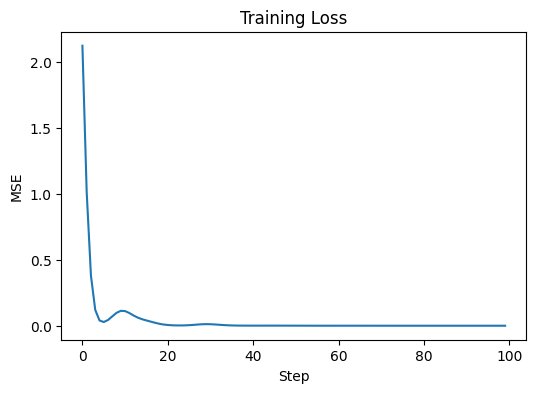

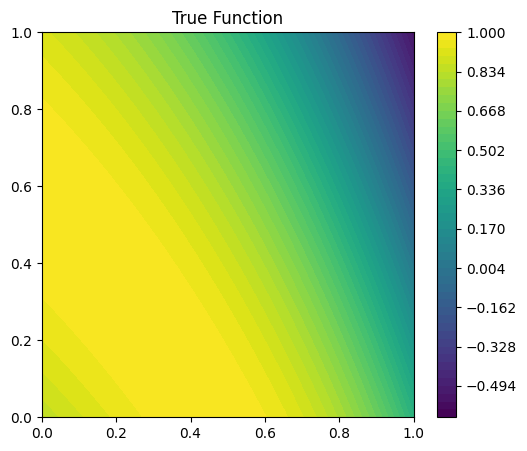

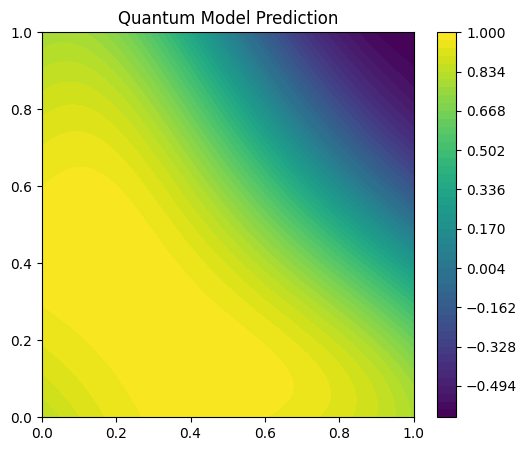

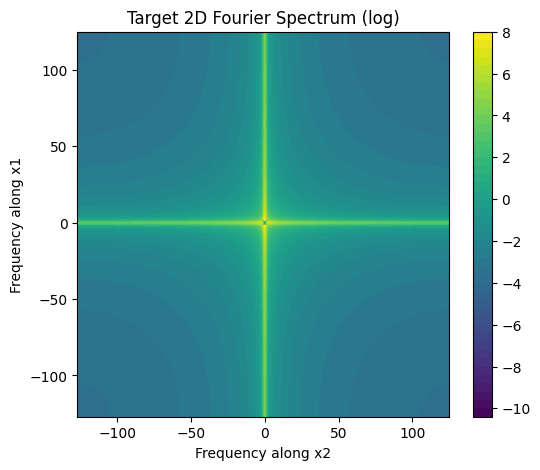

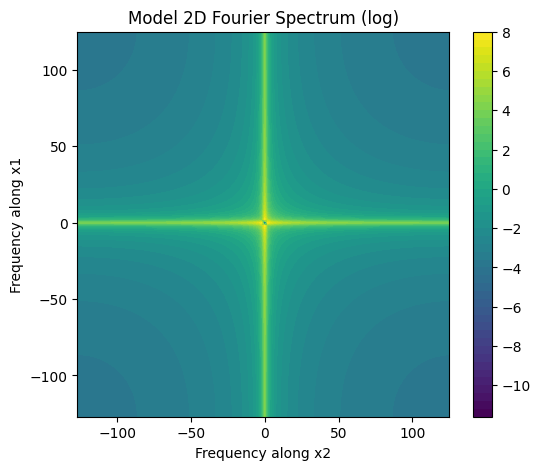

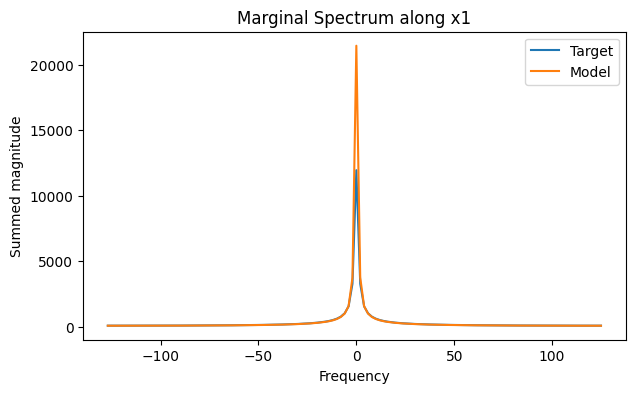

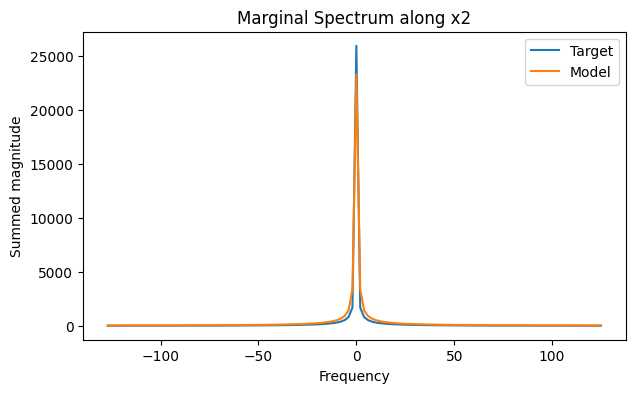


Top 10 Fourier modes: TARGET
 1. (fx1, fx2)=(1.9844, 0.0000), |F|=2.648175e+03
 2. (fx1, fx2)=(-1.9844, 0.0000), |F|=2.648175e+03
 3. (fx1, fx2)=(3.9688, 0.0000), |F|=1.304407e+03
 4. (fx1, fx2)=(-3.9688, 0.0000), |F|=1.304407e+03
 5. (fx1, fx2)=(0.0000, -1.9844), |F|=1.207129e+03
 6. (fx1, fx2)=(0.0000, 1.9844), |F|=1.207129e+03
 7. (fx1, fx2)=(5.9531, 0.0000), |F|=8.672284e+02
 8. (fx1, fx2)=(-5.9531, 0.0000), |F|=8.672284e+02
 9. (fx1, fx2)=(7.9375, 0.0000), |F|=6.501227e+02
10. (fx1, fx2)=(-7.9375, 0.0000), |F|=6.501227e+02

Top 10 Fourier modes: MODEL
 1. (fx1, fx2)=(-1.9844, 0.0000), |F|=2.430954e+03
 2. (fx1, fx2)=(1.9844, 0.0000), |F|=2.430954e+03
 3. (fx1, fx2)=(0.0000, 1.9844), |F|=2.207285e+03
 4. (fx1, fx2)=(0.0000, -1.9844), |F|=2.207285e+03
 5. (fx1, fx2)=(-3.9688, 0.0000), |F|=1.170377e+03
 6. (fx1, fx2)=(3.9688, 0.0000), |F|=1.170377e+03
 7. (fx1, fx2)=(0.0000, 3.9688), |F|=1.078707e+03
 8. (fx1, fx2)=(0.0000, -3.9688), |F|=1.078707e+03
 9. (fx1, fx2)=(-5.9531, 0.0000)

In [21]:
import torch
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

# ======================
# 1. Seed
# ======================
seed = 13202050
torch.manual_seed(seed)

# ======================
# 2. Target function
# f(x1, x2) = sin(exp(x1) + x2)
# ======================
def f(x):
    return torch.sin(torch.exp(x[:, 0]) + x[:, 1])

# ======================
# 3. Generate data
# train: [0, 0.5]^2
# test : [0.5, 1]^2
# ======================
N = 1000

train_input = torch.zeros(N, 2)
test_input  = torch.zeros(N, 2)

train_ranges = torch.tensor([[0.0, 0.5], [0.0, 0.5]])
test_ranges  = torch.tensor([[0.5, 1.0], [0.5, 1.0]])

for i in range(2):
    train_input[:, i] = torch.rand(N) * (train_ranges[i, 1] - train_ranges[i, 0]) + train_ranges[i, 0]
    test_input[:, i]  = torch.rand(N) * (test_ranges[i, 1] - test_ranges[i, 0]) + test_ranges[i, 0]

train_label = f(train_input)
test_label  = f(test_input)

# ======================
# 4. Quantum model
# ======================
dev = qml.device("default.qubit", wires=2)
scaling = 1.0

def S(x):
    qml.RY(scaling * x[0], wires=0)
    qml.RY(scaling * x[1], wires=1)
    qml.RZ(scaling * x[0], wires=0)
    qml.RZ(scaling * x[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RZ(scaling * x[0] * x[1], wires=1)
    qml.CNOT(wires=[0, 1])

def W(theta):
    qml.Rot(theta[0, 0], theta[1, 0], theta[2, 0], wires=0)
    qml.Rot(theta[0, 1], theta[1, 1], theta[2, 1], wires=1)
    qml.CZ(wires=[0, 1])

@qml.qnode(dev, interface="torch")
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])
    return qml.expval(qml.PauliZ(0))

# ======================
# 5. Initialize weights
# ======================
r = 3
weights = torch.randn((r + 1, 3, 2), requires_grad=True)

# ======================
# 6. Optimizer
# ======================
optimizer = torch.optim.Adam([weights], lr=0.1)

# ======================
# 7. Training
# ======================
steps = 100
loss_history = []

for step in range(steps):
    optimizer.zero_grad()
    preds = torch.stack([serial_quantum_model(weights, x_) for x_ in train_input])
    loss = torch.mean((preds - train_label) ** 2)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if step % 10 == 0:
        print(f"Step {step:3d} | Train Loss = {loss.item():.6f}")

# ======================
# 8. Final Train/Test MSE
# ======================
with torch.no_grad():
    train_preds = torch.stack([serial_quantum_model(weights, x_) for x_ in train_input])
    test_preds  = torch.stack([serial_quantum_model(weights, x_) for x_ in test_input])

    train_mse = torch.mean((train_preds - train_label) ** 2).item()
    test_mse  = torch.mean((test_preds - test_label) ** 2).item()

print(f"\nTrain MSE = {train_mse:.6f}")
print(f"Test  MSE = {test_mse:.6f}")

# ======================
# 9. Plot training loss
# ======================
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# ======================
# 10. Visualization on full domain [0,1]^2
# ======================
grid_vis = 50
x1 = torch.linspace(0, 1, grid_vis)
x2 = torch.linspace(0, 1, grid_vis)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

Z_true = torch.sin(torch.exp(X1) + X2)
Z_pred = torch.zeros_like(Z_true)

with torch.no_grad():
    for i in range(grid_vis):
        for j in range(grid_vis):
            x_in = torch.tensor([X1[i, j], X2[i, j]], dtype=weights.dtype)
            Z_pred[i, j] = serial_quantum_model(weights, x_in)

vminn = min(Z_true.min().item(), Z_pred.min().item())
vmaxx = max(Z_true.max().item(), Z_pred.max().item())
levels = np.linspace(vminn, vmaxx, 50)

plt.figure(figsize=(6, 5))
plt.contourf(X1.numpy(), X2.numpy(), Z_true.numpy(), levels=levels)
plt.title("True Function")
plt.colorbar()
plt.show()

plt.figure(figsize=(6, 5))
plt.contourf(X1.numpy(), X2.numpy(), Z_pred.detach().numpy(), levels=levels)
plt.title("Quantum Model Prediction")
plt.colorbar()
plt.show()

# ======================
# 11. Fourier analysis on test domain [0.5,1]^2
# ======================
grid_size = 128
x1_test = torch.linspace(0.5, 1.0, grid_size)
x2_test = torch.linspace(0.5, 1.0, grid_size)
X1_test, X2_test = torch.meshgrid(x1_test, x2_test, indexing="ij")

Z_true_test = torch.sin(torch.exp(X1_test) + X2_test)
Z_pred_test = torch.zeros_like(Z_true_test)

with torch.no_grad():
    for i in range(grid_size):
        for j in range(grid_size):
            x_in = torch.tensor([X1_test[i, j], X2_test[i, j]], dtype=weights.dtype)
            Z_pred_test[i, j] = serial_quantum_model(weights, x_in)

Z_true_np = Z_true_test.detach().numpy()
Z_pred_np = Z_pred_test.detach().numpy()

# remove mean (DC)
Z_true_centered = Z_true_np - np.mean(Z_true_np)
Z_pred_centered = Z_pred_np - np.mean(Z_pred_np)

# FFT
F_true = np.fft.fftshift(np.fft.fft2(Z_true_centered))
F_pred = np.fft.fftshift(np.fft.fft2(Z_pred_centered))

Spec_true = np.abs(F_true)
Spec_pred = np.abs(F_pred)

# log spectrum for plotting
eps = 1e-12
LogSpec_true = np.log(Spec_true + eps)
LogSpec_pred = np.log(Spec_pred + eps)

dx1 = float(x1_test[1] - x1_test[0])
dx2 = float(x2_test[1] - x2_test[0])

freq_x1 = np.fft.fftshift(np.fft.fftfreq(grid_size, d=dx1))
freq_x2 = np.fft.fftshift(np.fft.fftfreq(grid_size, d=dx2))

# ======================
# 12. Plot 2D Fourier spectra
# ======================
plt.figure(figsize=(6, 5))
plt.contourf(freq_x2, freq_x1, LogSpec_true, levels=50)
plt.title("Target 2D Fourier Spectrum (log)")
plt.xlabel("Frequency along x2")
plt.ylabel("Frequency along x1")
plt.colorbar()
plt.show()

plt.figure(figsize=(6, 5))
plt.contourf(freq_x2, freq_x1, LogSpec_pred, levels=50)
plt.title("Model 2D Fourier Spectrum (log)")
plt.xlabel("Frequency along x2")
plt.ylabel("Frequency along x1")
plt.colorbar()
plt.show()

# ======================
# 13. Marginal spectra
# ======================
marginal_true_x1 = Spec_true.sum(axis=1)
marginal_pred_x1 = Spec_pred.sum(axis=1)

marginal_true_x2 = Spec_true.sum(axis=0)
marginal_pred_x2 = Spec_pred.sum(axis=0)

plt.figure(figsize=(7, 4))
plt.plot(freq_x1, marginal_true_x1, label="Target")
plt.plot(freq_x1, marginal_pred_x1, label="Model")
plt.title("Marginal Spectrum along x1")
plt.xlabel("Frequency")
plt.ylabel("Summed magnitude")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(freq_x2, marginal_true_x2, label="Target")
plt.plot(freq_x2, marginal_pred_x2, label="Model")
plt.title("Marginal Spectrum along x2")
plt.xlabel("Frequency")
plt.ylabel("Summed magnitude")
plt.legend()
plt.show()

# ======================
# 14. Top-k modes
# ======================
def top_k_modes(spec, freq1, freq2, k=10, ignore_dc=True):
    spec_copy = spec.copy()
    c0 = spec_copy.shape[0] // 2
    c1 = spec_copy.shape[1] // 2

    if ignore_dc:
        spec_copy[c0, c1] = 0.0

    flat = spec_copy.ravel()
    idx = np.argpartition(flat, -k)[-k:]
    idx = idx[np.argsort(flat[idx])[::-1]]

    modes = []
    for id_ in idx:
        i, j = np.unravel_index(id_, spec_copy.shape)
        modes.append((freq1[i], freq2[j], spec_copy[i, j]))
    return modes

top_true = top_k_modes(Spec_true, freq_x1, freq_x2, k=10)
top_pred = top_k_modes(Spec_pred, freq_x1, freq_x2, k=10)

print("\nTop 10 Fourier modes: TARGET")
for n, (fx1, fx2, mag) in enumerate(top_true, 1):
    print(f"{n:2d}. (fx1, fx2)=({fx1:.4f}, {fx2:.4f}), |F|={mag:.6e}")

print("\nTop 10 Fourier modes: MODEL")
for n, (fx1, fx2, mag) in enumerate(top_pred, 1):
    print(f"{n:2d}. (fx1, fx2)=({fx1:.4f}, {fx2:.4f}), |F|={mag:.6e}")

# ======================
# 15. Spectral overlap
# ======================
Spec_true_norm = Spec_true / (np.linalg.norm(Spec_true) + eps)
Spec_pred_norm = Spec_pred / (np.linalg.norm(Spec_pred) + eps)
spectral_overlap = np.sum(Spec_true_norm * Spec_pred_norm)

print(f"\nSpectral overlap = {spectral_overlap:.6f}")

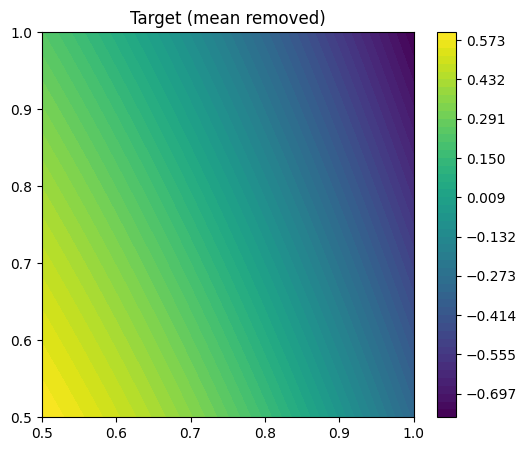

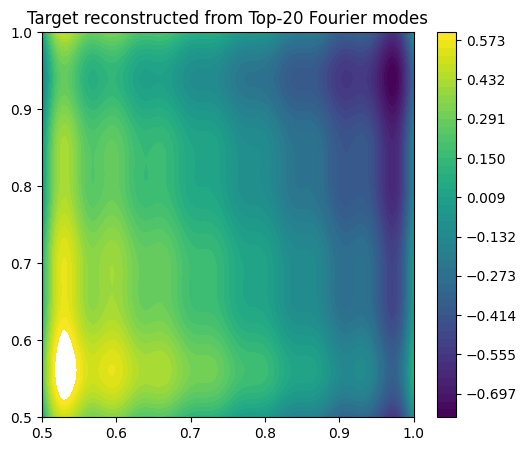

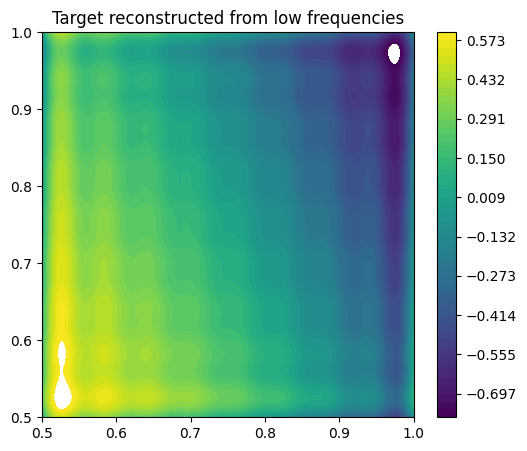

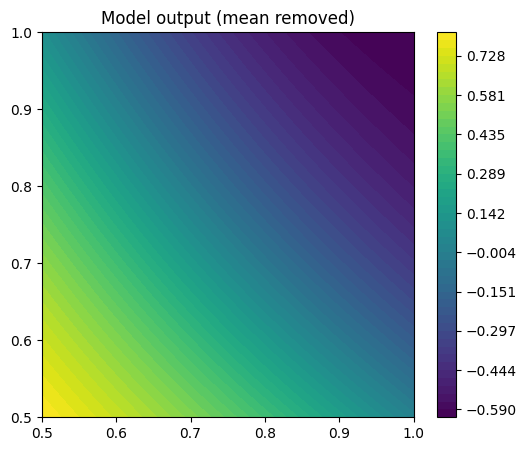

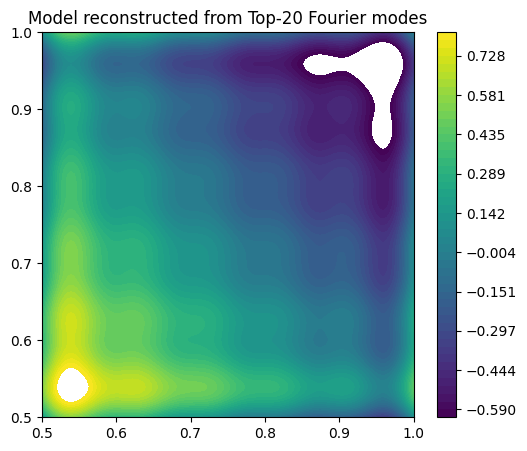

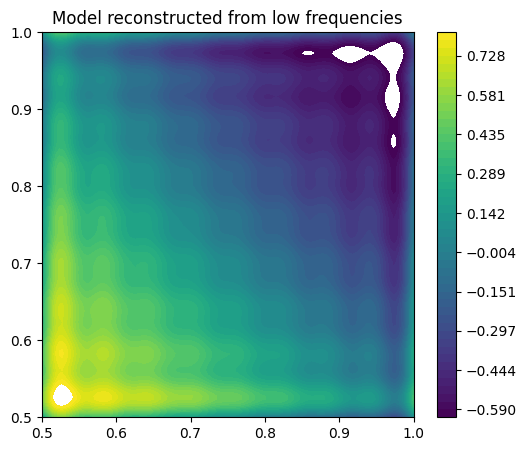

Target reconstruction MSE (Top-20 modes): 9.764372e-03
Target reconstruction MSE (Low-freq block): 7.054755e-03
Model  reconstruction MSE (Top-20 modes): 1.416429e-02
Model  reconstruction MSE (Low-freq block): 8.621476e-03


In [22]:
# ======================
# 16. Spectrum decomposition -> reconstructed function
# ======================

def reconstruct_top_k(F_shifted, k=20, keep_dc=False):
    """
    Reconstruct function using only top-k Fourier modes
    from a shifted FFT array.
    """
    F_copy = F_shifted.copy()
    h, w = F_copy.shape
    c0, c1 = h // 2, w // 2

    # flatten magnitude
    mag = np.abs(F_copy).copy()

    # optionally remove DC when selecting top-k
    if not keep_dc:
        mag[c0, c1] = 0.0

    # keep only top-k entries
    flat = mag.ravel()
    idx = np.argpartition(flat, -k)[-k:]

    mask = np.zeros_like(F_copy, dtype=bool)
    mask_flat = mask.ravel()
    mask_flat[idx] = True
    mask = mask_flat.reshape(F_copy.shape)

    # if keep_dc=True but DC not in top-k, force it to stay
    if keep_dc:
        mask[c0, c1] = True

    F_sparse = np.zeros_like(F_copy, dtype=complex)
    F_sparse[mask] = F_copy[mask]

    # inverse shift + ifft
    recon = np.fft.ifft2(np.fft.ifftshift(F_sparse)).real
    return recon, F_sparse


def reconstruct_low_freq(F_shifted, radius=8):
    """
    Reconstruct function using only a square low-frequency block
    centered at zero frequency.
    """
    F_copy = F_shifted.copy()
    h, w = F_copy.shape
    c0, c1 = h // 2, w // 2

    F_low = np.zeros_like(F_copy, dtype=complex)
    F_low[c0-radius:c0+radius+1, c1-radius:c1+radius+1] = \
        F_copy[c0-radius:c0+radius+1, c1-radius:c1+radius+1]

    recon = np.fft.ifft2(np.fft.ifftshift(F_low)).real
    return recon, F_low


# ---- reconstruct target ----
recon_true_topk, F_true_topk = reconstruct_top_k(F_true, k=20, keep_dc=False)
recon_true_low,  F_true_low  = reconstruct_low_freq(F_true, radius=8)

# ---- reconstruct model ----
recon_pred_topk, F_pred_topk = reconstruct_top_k(F_pred, k=20, keep_dc=False)
recon_pred_low,  F_pred_low  = reconstruct_low_freq(F_pred, radius=8)

# ----------------------
# 16A. Plot reconstructed functions
# ----------------------
levels_true = np.linspace(Z_true_centered.min(), Z_true_centered.max(), 50)
levels_pred = np.linspace(Z_pred_centered.min(), Z_pred_centered.max(), 50)

plt.figure(figsize=(6,5))
plt.contourf(X1_test.numpy(), X2_test.numpy(), Z_true_centered, levels=levels_true)
plt.title("Target (mean removed)")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,5))
plt.contourf(X1_test.numpy(), X2_test.numpy(), recon_true_topk, levels=levels_true)
plt.title("Target reconstructed from Top-20 Fourier modes")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,5))
plt.contourf(X1_test.numpy(), X2_test.numpy(), recon_true_low, levels=levels_true)
plt.title("Target reconstructed from low frequencies")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,5))
plt.contourf(X1_test.numpy(), X2_test.numpy(), Z_pred_centered, levels=levels_pred)
plt.title("Model output (mean removed)")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,5))
plt.contourf(X1_test.numpy(), X2_test.numpy(), recon_pred_topk, levels=levels_pred)
plt.title("Model reconstructed from Top-20 Fourier modes")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,5))
plt.contourf(X1_test.numpy(), X2_test.numpy(), recon_pred_low, levels=levels_pred)
plt.title("Model reconstructed from low frequencies")
plt.colorbar()
plt.show()

# ----------------------
# 16B. Reconstruction error
# ----------------------
err_true_topk = np.mean((recon_true_topk - Z_true_centered)**2)
err_true_low  = np.mean((recon_true_low  - Z_true_centered)**2)

err_pred_topk = np.mean((recon_pred_topk - Z_pred_centered)**2)
err_pred_low  = np.mean((recon_pred_low  - Z_pred_centered)**2)

print(f"Target reconstruction MSE (Top-20 modes): {err_true_topk:.6e}")
print(f"Target reconstruction MSE (Low-freq block): {err_true_low:.6e}")
print(f"Model  reconstruction MSE (Top-20 modes): {err_pred_topk:.6e}")
print(f"Model  reconstruction MSE (Low-freq block): {err_pred_low:.6e}")